# SpaceX Falcon 9 Launch Success Prediction

This project analyzes historical SpaceX Falcon 9 launch data to understand the factors that influence first-stage landing success. The analysis integrates data from the SpaceX API and web-scraped launch records, followed by data cleaning, exploratory data analysis, geospatial mapping, clustering, machine learning modeling, and dashboard visualization.

The goal is to explore patterns behind launch success and develop predictive models that estimate whether a Falcon 9 booster will land successfully.

## 1. Import Required Libraries

In this section, we import the Python libraries required for data collection, processing, analysis, visualization, and modeling.

Key libraries used in this project include:

- **Pandas** and **NumPy** for data manipulation
- **Requests** for API data collection
- **BeautifulSoup** for web scraping
- **Matplotlib** and **Plotly** for visualization
- **Folium** for geospatial analysis and mapping
- **Scikit-learn** for machine learning models
- **Dash** for building an interactive dashboard

In [321]:
# Requests allows us to make HTTP requests which we will use to get data from an API
import requests
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Datetime is a library that allows us to represent dates
import datetime

# Setting this option will print all collumns of a dataframe
pd.set_option('display.max_columns', None)
# Setting this option will print all of the data in a feature
pd.set_option('display.max_colwidth', None)

## 2. Data Collection from the SpaceX API

SpaceX provides a public API that allows access to historical launch data.  
We use the API endpoint below to retrieve information about past launches.

The API returns data in JSON format, which must be normalized and converted into a structured dataframe for analysis.

Key information retrieved includes:

- Rocket information
- Payload data
- Launch sites
- Core booster details
- Landing success outcomes

In [324]:
# Takes the dataset and uses the rocket column to call the API and append the data to the list
def getBoosterVersion(data):
    for x in data['rocket']:
       if x:
        response = requests.get("https://api.spacexdata.com/v4/rockets/"+str(x)).json()
        BoosterVersion.append(response['name'])

In [326]:
# Takes the dataset and uses the launchpad column to call the API and append the data to the list
def getLaunchSite(data):
    for x in data['launchpad']:
       if x:
         response = requests.get("https://api.spacexdata.com/v4/launchpads/"+str(x)).json()
         Longitude.append(response['longitude'])
         Latitude.append(response['latitude'])
         LaunchSite.append(response['name'])

In [328]:
# Takes the dataset and uses the payloads column to call the API and append the data to the lists
def getPayloadData(data):
    for load in data['payloads']:
       if load:
        response = requests.get("https://api.spacexdata.com/v4/payloads/"+load).json()
        PayloadMass.append(response['mass_kg'])
        Orbit.append(response['orbit'])# Takes the dataset and uses the payloads column to call the API and append the data to the lists

In [330]:
# Takes the dataset and uses the cores column to call the API and append the data to the lists
def getCoreData(data):
    for core in data['cores']:
            if core['core'] != None:
                response = requests.get("https://api.spacexdata.com/v4/cores/"+core['core']).json()
                Block.append(response['block'])
                ReusedCount.append(response['reuse_count'])
                Serial.append(response['serial'])
            else:
                Block.append(None)
                ReusedCount.append(None)
                Serial.append(None)
            Outcome.append(str(core['landing_success'])+' '+str(core['landing_type']))
            Flights.append(core['flight'])
            GridFins.append(core['gridfins'])
            Reused.append(core['reused'])
            Legs.append(core['legs'])
            LandingPad.append(core['landpad'])

In [332]:
spacex_url="https://api.spacexdata.com/v4/launches/past"

In [334]:
response = requests.get(spacex_url)

In [336]:
static_json_url='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/API_call_spacex_api.json'

In [338]:
response=requests.get(static_json_url)

In [340]:
response.status_code

200

## 2. Data Collection from the SpaceX API

SpaceX provides a public API that allows access to historical launch data.  
We use the API endpoint below to retrieve information about past launches.

The API returns data in JSON format, which must be normalized and converted into a structured dataframe for analysis.

Key information retrieved includes:

- Rocket information
- Payload data
- Launch sites
- Core booster details
- Landing success outcomes

In [343]:
data=response.json()
# Normalize the data using json_normalize
data = pd.json_normalize(data)

In [345]:
data.head()

,static_fire_date_utc,static_fire_date_unix,tbd,net,window,rocket,success,details,crew,ships,capsules,payloads,launchpad,auto_update,failures,flight_number,name,date_utc,date_unix,date_local,date_precision,upcoming,cores,id,fairings.reused,fairings.recovery_attempt,fairings.recovered,fairings.ships,links.patch.small,links.patch.large,links.reddit.campaign,links.reddit.launch,links.reddit.media,links.reddit.recovery,links.flickr.small,links.flickr.original,links.presskit,links.webcast,links.youtube_id,links.article,links.wikipedia,fairings
0,2006-03-17T00:00:00.000Z,1.142554e+09,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Engine failure at 33 seconds and loss of vehicle,[],[],[],[5eb0e4b5b6c3bb0006eeb1e1],5e9e4502f5090995de566f86,True,"[{'time': 33, 'altitude': None, 'reason': 'merlin engine failure'}]",1,FalconSat,2006-03-24T22:30:00.000Z,1143239400,2006-03-25T10:30:00+12:00,hour,False,"[{'core': '5e9e289df35918033d3b2623', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cd9ffd86e000604b32a,False,False,False,[],https://images2.imgbox.com/3c/0e/T8iJcSN3_o.png,https://images2.imgbox.com/40/e3/GypSkayF_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=0a_00nJ_Y88,0a_00nJ_Y88,https://www.space.com/2196-spacex-inaugural-falcon-1-rocket-lost-launch.html,https://en.wikipedia.org/wiki/DemoSat,NaN
1,None,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,False,"Successful first stage burn and transition to second stage, maximum altitude 289 km, Premature engine shutdown at T+7 min 30 s, Failed to reach orbit, Failed to recover first stage",[],[],[],[5eb0e4b6b6c3bb0006eeb1e2],5e9e4502f5090995de566f86,True,"[{'time': 301, 'altitude': 289, 'reason': 'harmonic oscillation leading to premature engine shutdown'}]",2,DemoSat,2007-03-21T01:10:00.000Z,1174439400,2007-03-21T13:10:00+12:00,hour,False,"[{'core': '5e9e289ef35918416a3b2624', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cdaffd86e000604b32b,False,False,False,[],https://images2.imgbox.com/4f/e3/I0lkuJ2e_o.png,https://images2.imgbox.com/be/e7/iNqsqVYM_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=Lk4zQ2wP-Nc,Lk4zQ2wP-Nc,https://www.space.com/3590-spacex-falcon-1-rocket-fails-reach-orbit.html,https://en.wikipedia.org/wiki/DemoSat,NaN
2,None,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Residual stage 1 thrust led to collision between stage 1 and stage 2,[],[],[],"[5eb0e4b6b6c3bb0006eeb1e3, 5eb0e4b6b6c3bb0006eeb1e4]",5e9e4502f5090995de566f86,True,"[{'time': 140, 'altitude': 35, 'reason': 'residual stage-1 thrust led to collision between stage 1 and stage 2'}]",3,Trailblazer,2008-08-03T03:34:00.000Z,1217734440,2008-08-03T15:34:00+12:00,hour,False,"[{'core': '5e9e289ef3591814873b2625', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cdbffd86e000604b32c,False,False,False,[],https://images2.imgbox.com/3d/86/cnu0pan8_o.png,https://images2.imgbox.com/4b/bd/d8UxLh4q_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=v0w9p3U8860,v0w9p3U8860,http://www.spacex.com/news/2013/02/11/falcon-1-flight-3-mission-summary,https://en.wikipedia.org/wiki/Trailblazer_(satellite),NaN
3,2008-09-20T00:00:00.000Z,1.221869e+09,False,False,0.0,5e9d0d95eda69955f709d1eb,True,"Ratsat was carried to orbit on the first successful orbital launch of any privately funded and developed, liquid-propelled carrier rocket, the SpaceX Falcon 1",[],[],[],[5eb0e4b7b6c3bb0006eeb1e5],5e9e4502f5090995de566f86,True,[],4,RatSat,2008-09-28T23:15:00.000Z,1222643700,2008-09-28T11:15:00+12:00,hour,False,"[{'core': '5e9e289ef3591855dc3b2626', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_succes

In [347]:
print(data.dtypes)
print(data.columns)


static_fire_date_utc          object
static_fire_date_unix        float64
tbd                             bool
net                             bool
window                       float64
rocket                        object
success                         bool
details                       object
crew                          object
ships                         object
capsules                      object
payloads                      object
launchpad                     object
auto_update                     bool
failures                      object
flight_number                  int64
name                          object
date_utc                      object
date_unix                      int64
date_local                    object
date_precision                object
upcoming                        bool
cores                         object
id                            object
fairings.reused               object
fairings.recovery_attempt     object
fairings.recovered            object
f

## 3. Data Cleaning and Preprocessing

The raw dataset obtained from the API contains nested fields, missing values, and unnecessary columns.  
This step focuses on preparing the data for analysis by performing the following tasks:

- Selecting relevant features
- Removing launches with multiple payloads or cores
- Handling missing values
- Converting data types
- Filtering Falcon 9 launches only

These steps ensure the dataset is clean, consistent, and suitable for further analysis and modeling.

In [350]:
# Lets take a subset of our dataframe keeping only the features we want and the flight number, and date_utc.
data.columns = data.columns.str.strip()
data = data[['rocket', 'payloads', 'launchpad', 'cores', 'flight_number', 'date_utc']]

# We will remove rows with multiple cores because those are falcon rockets with 2 extra rocket boosters and rows that have multiple payloads in a single rocket.
data = data[data['cores'].map(len)==1]
data = data[data['payloads'].map(len)==1]

# Since payloads and cores are lists of size 1 we will also extract the single value in the list and replace the feature.
data['cores'] = data['cores'].map(lambda x : x[0])
data['payloads'] = data['payloads'].map(lambda x : x[0])

# We also want to convert the date_utc to a datetime datatype and then extracting the date leaving the time
data['date'] = pd.to_datetime(data['date_utc']).dt.date

# Using the date we will restrict the dates of the launches
data = data[data['date'] <= datetime.date(2020, 11, 13)]

In [352]:
#Global variables 
BoosterVersion = []
PayloadMass = []
Orbit = []
LaunchSite = []
Outcome = []
Flights = []
GridFins = []
Reused = []
Legs = []
LandingPad = []
Block = []
ReusedCount = []
Serial = []
Longitude = []
Latitude = []

In [354]:
BoosterVersion

[]

In [356]:
# Call getBoosterVersion
getBoosterVersion(data)
BoosterVersion[0:5]

['Falcon 1', 'Falcon 1', 'Falcon 1', 'Falcon 1', 'Falcon 9']

In [357]:
getLaunchSite(data)

In [358]:
# Call getPayloadData
getPayloadData(data)

In [359]:
# Call getCoreData
getCoreData(data)

In [360]:
launch_dict = {'FlightNumber': list(data['flight_number']),
'Date': list(data['date']),
'BoosterVersion':BoosterVersion,
'PayloadMass':PayloadMass,
'Orbit':Orbit,
'LaunchSite':LaunchSite,
'Outcome':Outcome,
'Flights':Flights,
'GridFins':GridFins,
'Reused':Reused,
'Legs':Legs,
'LandingPad':LandingPad,
'Block':Block,
'ReusedCount':ReusedCount,
'Serial':Serial,
'Longitude': Longitude,
'Latitude': Latitude}

In [361]:
data=pd.DataFrame(launch_dict)
print(data)

    FlightNumber        Date BoosterVersion  PayloadMass Orbit  \
0              1  2006-03-24       Falcon 1         20.0   LEO   
1              2  2007-03-21       Falcon 1          NaN   LEO   
2              4  2008-09-28       Falcon 1        165.0   LEO   
3              5  2009-07-13       Falcon 1        200.0   LEO   
4              6  2010-06-04       Falcon 9          NaN   LEO   
..           ...         ...            ...          ...   ...   
89           102  2020-09-03       Falcon 9      15600.0  VLEO   
90           103  2020-10-06       Falcon 9      15600.0  VLEO   
91           104  2020-10-18       Falcon 9      15600.0  VLEO   
92           105  2020-10-24       Falcon 9      15600.0  VLEO   
93           106  2020-11-05       Falcon 9       3681.0   MEO   

         LaunchSite    Outcome  Flights  GridFins  Reused   Legs  \
0   Kwajalein Atoll  None None        1     False   False  False   
1   Kwajalein Atoll  None None        1     False   False  False   
2  

In [362]:
data.describe

<bound method NDFrame.describe of     FlightNumber        Date BoosterVersion  PayloadMass Orbit  \
0              1  2006-03-24       Falcon 1         20.0   LEO   
1              2  2007-03-21       Falcon 1          NaN   LEO   
2              4  2008-09-28       Falcon 1        165.0   LEO   
3              5  2009-07-13       Falcon 1        200.0   LEO   
4              6  2010-06-04       Falcon 9          NaN   LEO   
..           ...         ...            ...          ...   ...   
89           102  2020-09-03       Falcon 9      15600.0  VLEO   
90           103  2020-10-06       Falcon 9      15600.0  VLEO   
91           104  2020-10-18       Falcon 9      15600.0  VLEO   
92           105  2020-10-24       Falcon 9      15600.0  VLEO   
93           106  2020-11-05       Falcon 9       3681.0   MEO   

         LaunchSite    Outcome  Flights  GridFins  Reused   Legs  \
0   Kwajalein Atoll  None None        1     False   False  False   
1   Kwajalein Atoll  None None       

In [363]:
# Hint data['BoosterVersion']!='Falcon 1'
data_falcon9=data[data['BoosterVersion']!='Falcon 1']
print(data_falcon9['BoosterVersion'].unique())

['Falcon 9']


In [364]:
data_falcon9.loc[:,'FlightNumber'] = list(range(1, data_falcon9.shape[0]+1))
data_falcon9

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
4,1,2010-06-04,Falcon 9,NaN,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0003,-80.577366,28.561857
5,2,2012-05-22,Falcon 9,525.0,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0005,-80.577366,28.561857
6,3,2013-03-01,Falcon 9,677.0,ISS,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0007,-80.577366,28.561857
7,4,2013-09-29,Falcon 9,500.0,PO,VAFB SLC 4E,False Ocean,1,False,False,False,None,1.0,0,B1003,-120.610829,34.632093
8,5,2013-12-03,Falcon 9,3170.0,GTO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B1004,-80.577366,28.561857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,86,2020-09-03,Falcon 9,15600.0,VLEO,KSC LC 39A,True ASDS,2,True,True,True,5e9e3032383ecb6bb234e7ca,5.0,12,B1060,-80.603956,28.608058
90,87,2020-10-06,Falcon 9,15600.0,VLEO,KSC LC 39A,True ASDS,3,True,True,True,5e9e3032383ecb6bb234e7ca,5.0,13,B1058,-80.603956,28.608058
91,88,2020-10-18,Falcon 9,15600.0,VLEO,KSC LC 39A,True ASDS,6,True,True,True,5e9e3032383ecb6bb234e7ca,5.0,12,B1051,-80.603956,28.608058
92,89,2020-10-24,Falcon 9,15600.0,VLEO,CCSFS SLC 40,True ASDS,3,True,True,True,5e9e3033383ecbb9e534e7cc,5.0,12,B1060,-80.577366,28.561857


In [365]:
data_falcon9.isnull().sum()

FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        5
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
dtype: int64

## 4. Feature Engineering

The initial dataset contains identifiers for rockets, launchpads, payloads, and cores.  
Additional API calls are used to retrieve more detailed information related to these identifiers.

The following attributes are extracted:

- Booster version
- Launch site location
- Payload mass
- Orbit type
- Landing outcomes
- Booster reuse information

These engineered features enrich the dataset and provide important predictors for landing success.

In [368]:
# Calculate the mean value of PayloadMass column
payload_mean = data_falcon9['PayloadMass'].mean()
print(payload_mean)
# Replace the np.nan values with its mean value
# Replace NaN values in PayloadMass with the mean
data_falcon9['PayloadMass'] = data_falcon9['PayloadMass'].replace(np.nan, payload_mean)
print(data_falcon9['PayloadMass'])

6123.547647058824
4      6123.547647
5       525.000000
6       677.000000
7       500.000000
8      3170.000000
          ...     
89    15600.000000
90    15600.000000
91    15600.000000
92    15600.000000
93     3681.000000
Name: PayloadMass, Length: 90, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_4332\1923020112.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [369]:
data_falcon9.to_csv('dataset_part_1.csv', index=False)

In [370]:
!pip3 install beautifulsoup4
!pip3 install requests

## 5. Web Scraping Launch Records

In addition to the SpaceX API, launch data is collected from Wikipedia using web scraping techniques.

Using the **Requests** library and **BeautifulSoup**, launch tables are extracted from the Falcon 9 launch records page.

Information collected includes:

- Flight number
- Launch site
- Payload
- Orbit
- Launch outcome
- Booster landing result

The scraped data is then structured into a dataframe and saved as a CSV dataset.

In [372]:
import sys

import requests
from bs4 import BeautifulSoup
import re
import unicodedata
import pandas as pd

In [373]:
def date_time(table_cells):
    """
    This function returns the data and time from the HTML  table cell
    Input: the  element of a table data cell extracts extra row
    """
    return [data_time.strip() for data_time in list(table_cells.strings)][0:2]

def booster_version(table_cells):
    """
    This function returns the booster version from the HTML  table cell 
    Input: the  element of a table data cell extracts extra row
    """
    out=''.join([booster_version for i,booster_version in enumerate( table_cells.strings) if i%2==0][0:-1])
    return out

def landing_status(table_cells):
    """
    This function returns the landing status from the HTML table cell 
    Input: the  element of a table data cell extracts extra row
    """
    out=[i for i in table_cells.strings][0]
    return out


def get_mass(table_cells):
    mass=unicodedata.normalize("NFKD", table_cells.text).strip()
    if mass:
        mass.find("kg")
        new_mass=mass[0:mass.find("kg")+2]
    else:
        new_mass=0
    return new_mass


def extract_column_from_header(row):
    """
    This function returns the landing status from the HTML table cell 
    Input: the  element of a table data cell extracts extra row
    """
    if (row.br):
        row.br.extract()
    if row.a:
        row.a.extract()
    if row.sup:
        row.sup.extract()
        
    colunm_name = ' '.join(row.contents)
    
    # Filter the digit and empty names
    if not(colunm_name.strip().isdigit()):
        colunm_name = colunm_name.strip()
        return colunm_name    


In [374]:
static_url = "https://en.wikipedia.org/w/index.php?title=List_of_Falcon_9_and_Falcon_Heavy_launches&oldid=1027686922"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/91.0.4472.124 Safari/537.36"
}

In [376]:
# use requests.get() method with the provided static_url and headers
# assign the response to a object
response = requests.get(static_url, headers=headers)

# Check if request was successful
if response.status_code == 200:
    print("Request successful!")
else:
    print("Request failed with status code:", response.status_code)

Request successful!


In [377]:
# Use BeautifulSoup() to create a BeautifulSoup object from a response text content
# Create a BeautifulSoup object from the response text
soup = BeautifulSoup(response.text, 'html.parser')

# Optional: check the type to confirm
print(type(soup))  # <class 'bs4.BeautifulSoup'>

# Optional: print the first 500 characters of the HTML
print(soup.prettify()[:500])

<class 'bs4.BeautifulSoup'>
<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled wp25easte


In [378]:
# Use soup.title attribute
# Print the page title
print(soup.title)

# Optional: print only the text of the title
print(soup.title.text)

<title>List of Falcon 9 and Falcon Heavy launches - Wikipedia</title>
List of Falcon 9 and Falcon Heavy launches - Wikipedia


In [379]:
# Use the find_all function in the BeautifulSoup object, with element type `table`
# Assign the result to a list called `html_tables`
# Find all table elements in the BeautifulSoup object
html_tables = soup.find_all('table')

# Check how many tables were found
print(f"Number of tables found: {len(html_tables)}")

# Optional: print the first table to inspect
print(html_tables[0])


Number of tables found: 25
<table class="col-begin" role="presentation">
<tbody><tr>
<td class="col-break">
<div class="mw-heading mw-heading3"><h3 id="Rocket_configurations">Rocket configurations</h3></div>
<div class="chart noresize" style="padding-top:10px;margin-top:1em;max-width:420px;">
<div style="position:relative;min-height:320px;min-width:420px;max-width:420px;">
<div style="float:right;position:relative;min-height:240px;min-width:320px;max-width:320px;border-left:1px black solid;border-bottom:1px black solid;">
<div style="position:absolute;left:3px;top:224px;height:15px;min-width:18px;max-width:18px;color:inherit;background-color:LightSteelBlue;-webkit-print-color-adjust:exact;border:1px solid LightSteelBlue;border-bottom:none;overflow:hidden;" title="[[Falcon 9 v1.0]]: 2"></div>
<div style="position:absolute;left:55px;top:224px;height:15px;min-width:18px;max-width:18px;color:inherit;background-color:LightSteelBlue;-webkit-print-color-adjust:exact;border:1px solid LightStee

In [380]:
print(response.status_code)

200


In [381]:
# Get all tables without filtering by class
html_tables = soup.find_all('table')
print(f"Number of tables found: {len(html_tables)}")

Number of tables found: 25


In [382]:
#column_names = []

# Apply find_all() function with `th` element on first_launch_table
# Iterate each th element and apply the provided extract_column_from_header() to get a column name

# Append the Non-empty column name (`if name is not None and len(name) > 0`) into a list called column_names
# Suppose first_launch_table is the BeautifulSoup object of the first table
# Assuming extract_column_from_header() and first_launch_table are defined

# Assume `soup` is the Beautiful Soup object for the entire page
first_launch_table = soup.find('table', class_='wikitable')

# Now, rerun the code to find the headers
column_names = []
if first_launch_table: # Check if the table was found
    for th in first_launch_table.find_all('th'):
        name = extract_column_from_header(th)
        if name is not None and len(name) > 0:
            column_names.append(name)

print(column_names)

['Flight No.', 'Date and time ( )', 'Launch site', 'Payload', 'Payload mass', 'Orbit', 'Customer', 'Launch outcome']


In [384]:
launch_dict= dict.fromkeys(column_names)

# Remove an irrelvant column
del launch_dict['Date and time ( )']

# Let's initial the launch_dict with each value to be an empty list
launch_dict['Flight No.'] = []
launch_dict['Launch site'] = []
launch_dict['Payload'] = []
launch_dict['Payload mass'] = []
launch_dict['Orbit'] = []
launch_dict['Customer'] = []
launch_dict['Launch outcome'] = []
# Added some new columns
launch_dict['Version Booster']=[]
launch_dict['Booster landing']=[]
launch_dict['Date']=[]
launch_dict['Time']=[]

In [385]:
extracted_row = 0
launch_list = []  # List to store all launch dictionaries

# Extract each table
for table_number, table in enumerate(soup.find_all('table', "wikitable plainrowheaders collapsible")):
    # Get table rows
    for rows in table.find_all("tr"):
        # Check if first table heading is a number corresponding to flight number
        if rows.th:
            if rows.th.string:
                flight_number = rows.th.string.strip()
                flag = flight_number.isdigit()
            else:
                flag = False
        else:
            flag = False
        
        # Get table cells
        row = rows.find_all('td')
        
        # If it is a valid flight number, save row in a dictionary
        if flag:
            extracted_row += 1
            launch_dict = {}  # Initialize dictionary for this launch
            
            # Flight Number
            launch_dict['Flight No.'] = flight_number
            
            # Date and Time
            datatimelist = date_time(row[0])
            launch_dict['Date'] = datatimelist[0].strip(',')
            launch_dict['Time'] = datatimelist[1]
            
            # Booster Version
            bv = booster_version(row[1])
            if not bv and row[1].a:
                bv = row[1].a.string
            launch_dict['Version Booster'] = bv
            
            # Launch Site
            launch_site = row[2].a.string if row[2].a else None
            launch_dict['Launch Site'] = launch_site
            
            # Payload
            payload = row[3].a.string if row[3].a else None
            launch_dict['Payload'] = payload
            
            # Payload Mass
            payload_mass = get_mass(row[4])
            launch_dict['Payload mass'] = payload_mass
            
            # Orbit
            orbit = row[5].a.string if row[5].a else None
            launch_dict['Orbit'] = orbit
            
            # Customer
            customer = row[6].a.string if row[6].a else None
            launch_dict['Customer'] = customer
            
            # Launch Outcome
            launch_outcome = list(row[7].strings)[0] if row[7].strings else None
            launch_dict['Launch outcome'] = launch_outcome
            
            # Booster Landing
            booster_landing = landing_status(row[8])
            launch_dict['Booster landing'] = booster_landing
            
            # Append this launch to the list
            launch_list.append(launch_dict)


In [386]:
import pandas as pd
df_launches = pd.DataFrame(launch_list)
df_launches.head()

,Flight No.,Date,Time,Version Booster,Launch Site,Payload,Payload mass,Orbit,Customer,Launch outcome,Booster landing
0,1,4 June 2010,18:45,F9 v1.07B0003.18,CCAFS,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success\n,Failure
1,2,8 December 2010,15:43,F9 v1.07B0004.18,CCAFS,Dragon,0,LEO,NASA,Success,Failure
2,3,22 May 2012,07:44,F9 v1.07B0005.18,CCAFS,Dragon,525 kg,LEO,NASA,Success,No attempt\n
3,4,8 October 2012,00:35,F9 v1.07B0006.18,CCAFS,SpaceX CRS-1,"4,700 kg",LEO,NASA,Success\n,No attempt
4,5,1 March 2013,15:10,F9 v1.07B0007.18,CCAFS,SpaceX CRS-2,"4,877 kg",LEO,NASA,Success\n,No attempt\n


In [387]:
df= pd.DataFrame({ key:pd.Series(value) for key, value in launch_dict.items() })

In [388]:
print(df)

  Flight No.         Date   Time Version Booster Launch Site Payload  \
0        121  6 June 2021  04:26           F9 B5       CCSFS   SXM-8   

  Payload mass Orbit   Customer Launch outcome Booster landing  
0     7,000 kg   GTO  Sirius XM      Success\n         Success  


In [389]:
df.to_csv('spacex_web_scraped.csv', index=False)

## 6. Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps identify patterns and relationships within the dataset.

In this section we analyze:

- Launch success rates
- Launch site performance
- Payload mass distribution
- Orbit types
- Booster landing outcomes

These insights help understand the factors that may influence launch success.

In [391]:
!pip install pandas
!pip install numpy

In [394]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np

In [402]:
df=pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv")
df.head(10)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857
5,6,2014-01-06,Falcon 9,3325.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1005,-80.577366,28.561857
6,7,2014-04-18,Falcon 9,2296.000000,ISS,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1.0,0,B1006,-80.577366,28.561857
7,8,2014-07-14,Falcon 9,1316.000000,LEO,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1.0,0,B1007,-80.577366,28.561857
8,9,2014-08-05,Falcon 9,4535.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1008,-80.577366,28.561857
9,10,2014-09-07,Falcon 9,4428.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1011,-80.577366,28.561857


In [403]:
df.isnull().sum()/len(df)*100

FlightNumber       0.000000
Date               0.000000
BoosterVersion     0.000000
PayloadMass        0.000000
Orbit              0.000000
LaunchSite         0.000000
Outcome            0.000000
Flights            0.000000
GridFins           0.000000
Reused             0.000000
Legs               0.000000
LandingPad        28.888889
Block              0.000000
ReusedCount        0.000000
Serial             0.000000
Longitude          0.000000
Latitude           0.000000
dtype: float64

In [404]:
df.dtypes

FlightNumber        int64
Date               object
BoosterVersion     object
PayloadMass       float64
Orbit              object
LaunchSite         object
Outcome            object
Flights             int64
GridFins             bool
Reused               bool
Legs                 bool
LandingPad         object
Block             float64
ReusedCount         int64
Serial             object
Longitude         float64
Latitude          float64
dtype: object

In [405]:
df.columns

Index(['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit',
       'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs',
       'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude',
       'Latitude'],
      dtype='object')

In [406]:
# Apply value_counts() on column LaunchSite
df.LaunchSite.value_counts()

LaunchSite
CCAFS SLC 40    55
KSC LC 39A      22
VAFB SLC 4E     13
Name: count, dtype: int64

In [407]:
# Apply value_counts on Orbit column
df.Orbit.value_counts().drop('GTO')

Orbit
ISS      21
VLEO     14
PO        9
LEO       7
SSO       5
MEO       3
ES-L1     1
HEO       1
SO        1
GEO       1
Name: count, dtype: int64

In [408]:
# landing_outcomes = values on Outcome column
landing_outcomes=df.Outcome.value_counts()
print(landing_outcomes)

Outcome
True ASDS      41
None None      19
True RTLS      14
False ASDS      6
True Ocean      5
False Ocean     2
None ASDS       2
False RTLS      1
Name: count, dtype: int64


In [409]:
for i,outcome in enumerate(landing_outcomes.keys()):
    print(i,outcome)

0 True ASDS
1 None None
2 True RTLS
3 False ASDS
4 True Ocean
5 False Ocean
6 None ASDS
7 False RTLS


In [410]:
bad_outcomes=set(landing_outcomes.keys()[[1,3,5,6,7]])
bad_outcomes

{'False ASDS', 'False Ocean', 'False RTLS', 'None ASDS', 'None None'}

In [411]:
# landing_class = 0 if bad_outcome
# landing_class = 1 otherwise
landing_class = [0 if outcome in bad_outcomes else 1 for outcome in df['Outcome']]
df['LandingClass'] = landing_class
print(df["LandingClass"])

0     0
1     0
2     0
3     0
4     0
     ..
85    1
86    1
87    1
88    1
89    1
Name: LandingClass, Length: 90, dtype: int64


In [412]:
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,LandingClass
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [413]:
df.columns

Index(['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit',
       'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs',
       'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude',
       'LandingClass'],
      dtype='object')

In [414]:
df.LandingClass.head(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    1
7    1
8    0
9    0
Name: LandingClass, dtype: int64

In [415]:
df.LandingClass.mean()

0.6666666666666666

In [416]:
df.to_csv("dataset_part_2.csv", index=False)

## SQL NOTEBOOK

In [435]:
!pip install sqlalchemy==1.3.9

  Using cached sqlalchemy-1.3.9-cp312-cp312-win_amd64.whl
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 2.0.48
    Uninstalling SQLAlchemy-2.0.48:
      Successfully uninstalled SQLAlchemy-2.0.48


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aext-project-filebrowser-server 4.1.0 requires anaconda-cloud-auth>=0.7.1, which is not installed.
aext-toolbox 4.1.0 requires anaconda-cloud-auth>=0.7.1, which is not installed.
aext-project-filebrowser-server 4.1.0 requires sqlalchemy>=2.0.29, but you have sqlalchemy 1.3.9 which is incompatible.
ipython-sql 0.5.0 requires sqlalchemy>=2.0, but you have sqlalchemy 1.3.9 which is incompatible.


In [436]:
!pip install ipython-sql
!pip install ipython-sql prettytable

  Using cached sqlalchemy-2.0.48-cp312-cp312-win_amd64.whl.metadata (9.8 kB)
Using cached sqlalchemy-2.0.48-cp312-cp312-win_amd64.whl (2.1 MB)
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 1.3.9
    Uninstalling SQLAlchemy-1.3.9:
      Successfully uninstalled SQLAlchemy-1.3.9


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aext-project-filebrowser-server 4.1.0 requires anaconda-cloud-auth>=0.7.1, which is not installed.
aext-toolbox 4.1.0 requires anaconda-cloud-auth>=0.7.1, which is not installed.


In [437]:
%load_ext sql

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [438]:
import csv, sqlite3
import prettytable
prettytable.DEFAULT = 'DEFAULT'

con = sqlite3.connect("my_data1.db")
cur = con.cursor()

In [439]:
!pip install -q pandas

In [440]:
%sql sqlite:///my_data1.db

In [441]:
import pandas as pd
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_2/data/Spacex.csv")
df.to_sql("SPACEXTBL", con, if_exists='replace', index=False,method="multi")
df.head()

,Date,Time (UTC),Booster_Version,Launch_Site,Payload,PAYLOAD_MASS__KG_,Orbit,Customer,Mission_Outcome,Landing_Outcome
0,2010-06-04,18:45:00,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,Failure (parachute)
1,2010-12-08,15:43:00,F9 v1.0 B0004,CCAFS LC-40,"Dragon demo flight C1, two CubeSats, barrel of Brouere cheese",0,LEO (ISS),NASA (COTS) NRO,Success,Failure (parachute)
2,2012-05-22,7:44:00,F9 v1.0 B0005,CCAFS LC-40,Dragon demo flight C2,525,LEO (ISS),NASA (COTS),Success,No attempt
3,2012-10-08,0:35:00,F9 v1.0 B0006,CCAFS LC-40,SpaceX CRS-1,500,LEO (ISS),NASA (CRS),Success,No attempt
4,2013-03-01,15:10:00,F9 v1.0 B0007,CCAFS LC-40,SpaceX CRS-2,677,LEO (ISS),NASA (CRS),Success,No attempt


In [442]:
#DROP THE TABLE IF EXISTS

%sql DROP TABLE IF EXISTS SPACEXTABLE;

 * sqlite:///my_data1.db
Done.


[]

In [455]:
%sql create table SPACEXTABLE as select * from SPACEXTBL where Date is not null

 * sqlite:///my_data1.db
Done.


[]

### Task 1
Display the names of the unique launch sites in the space mission
Selection deleted


In [462]:
%sql SELECT DISTINCT "Landing_Outcome" FROM "SPACEXTABLE";

 * sqlite:///my_data1.db
Done.


Landing_Outcome
Failure (parachute)
No attempt
Uncontrolled (ocean)
Controlled (ocean)
Failure (drone ship)
Precluded (drone ship)
Success (ground pad)
Success (drone ship)
Success
Failure


### Task 2
Display 5 records where launch sites begin with the string 'CCA'¶

In [493]:
%sql SELECT * FROM SPACEXTABLE WHERE "Launch_Site" LIKE 'CCA%' LIMIT 5;

 * sqlite:///my_data1.db
Done.


Date,Time (UTC),Booster_Version,Launch_Site,Payload,PAYLOAD_MASS__KG_,Orbit,Customer,Mission_Outcome,Landing_Outcome
2010-06-04,18:45:00,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,Failure (parachute)
2010-12-08,15:43:00,F9 v1.0 B0004,CCAFS LC-40,"Dragon demo flight C1, two CubeSats, barrel of Brouere cheese",0,LEO (ISS),NASA (COTS) NRO,Success,Failure (parachute)
2012-05-22,7:44:00,F9 v1.0 B0005,CCAFS LC-40,Dragon demo flight C2,525,LEO (ISS),NASA (COTS),Success,No attempt
2012-10-08,0:35:00,F9 v1.0 B0006,CCAFS LC-40,SpaceX CRS-1,500,LEO (ISS),NASA (CRS),Success,No attempt
2013-03-01,15:10:00,F9 v1.0 B0007,CCAFS LC-40,SpaceX CRS-2,677,LEO (ISS),NASA (CRS),Success,No attempt


### Task 3
Display the total payload mass carried by boosters launched by NASA (CRS)¶

In [496]:
%sql SELECT SUM("PAYLOAD_MASS__KG_") FROM SPACEXTABLE WHERE "Customer" = 'NASA (CRS)';

 * sqlite:///my_data1.db
Done.


SUM(PAYLOAD_MASS__KG_)
45596


### Task 4
Display average payload mass carried by booster version F9 v1.1

In [468]:
%sql SELECT AVG("PAYLOAD_MASS__KG_") FROM SPACEXTABLE WHERE "Booster_Version" = 'F9 v1.1';

 * sqlite:///my_data1.db
Done.


AVG(PAYLOAD_MASS__KG_)
2928.4


### Task 5
List the date when the first succesful landing outcome in ground pad was acheived.
Hint:Use min function

In [501]:
%sql SELECT MIN(Date) FROM SPACEXTABLE WHERE "Landing_Outcome" = 'Success (ground pad)';

 * sqlite:///my_data1.db
Done.


MIN(Date)
2015-12-22


### List the names of the boosters which have success in drone ship and have payload mass greater than 4000 but less than 6000¶

In [505]:
%sql SELECT "Booster_Version" FROM SPACEXTABLE WHERE "Landing_Outcome" = 'Success (drone ship)' AND "PAYLOAD_MASS__KG_" BETWEEN 4000 AND 6000;

 * sqlite:///my_data1.db
Done.


Booster_Version
F9 FT B1022
F9 FT B1026
F9 FT B1021.2
F9 FT B1031.2


### Task 7
List the total number of successful and failure mission outcomes

In [508]:
%sql SELECT TRIM("Mission_Outcome"), COUNT(TRIM("Mission_Outcome")) AS Total_Count FROM SPACEXTABLE GROUP BY TRIM("Mission_Outcome");

 * sqlite:///my_data1.db
Done.


TRIM(Mission_Outcome),Total_Count
Failure (in flight),1
Success,99
Success (payload status unclear),1


### Task 8
List all the booster_versions that have carried the maximum payload mass, using a subquery with a suitable aggregate function.

In [511]:
%sql SELECT "Booster_Version" FROM SPACEXTABLE WHERE "PAYLOAD_MASS__KG_" = (SELECT MAX("PAYLOAD_MASS__KG_") FROM SPACEXTABLE);

 * sqlite:///my_data1.db
Done.


Booster_Version
F9 B5 B1048.4
F9 B5 B1049.4
F9 B5 B1051.3
F9 B5 B1056.4
F9 B5 B1048.5
F9 B5 B1051.4
F9 B5 B1049.5
F9 B5 B1060.2
F9 B5 B1058.3
F9 B5 B1051.6


In [523]:
import pandas as pd
result = %sql SELECT "Booster_Version " FROM SPACEXTABLE WHERE "PAYLOAD_MASS__KG_"
=(SELECT MAX("PAYLOAD_MASS__KG_") FROM SPACEXTABLE);
df = result.DataFrame()
print(df)

SyntaxError: invalid syntax (2114742429.py, line 3)

### Task 9
List the records which will display the month names, failure landing_outcomes in drone ship ,booster versions, launch_site for the months in year 2015.
Note: SQLLite does not support monthnames. So you need to use substr(Date, 6,2) as month to get the months and substr(Date,0,5)='2015' for year.

In [526]:
%sql SELECT CASE substr(Date, 6, 2) \
      WHEN '01' THEN 'January' \
      WHEN '02' THEN 'February' \
      WHEN '03' THEN 'March' \
      WHEN '04' THEN 'April' \
      WHEN '05' THEN 'May' \
      WHEN '06' THEN 'June' \
      WHEN '07' THEN 'July' \
      WHEN '08' THEN 'August' \
      WHEN '09' THEN 'September' \
      WHEN '10' THEN 'October' \
      WHEN '11' THEN 'November' \
      WHEN '12' THEN 'December' \
      END AS Month, \
      "Landing_Outcome", \
      "Booster_Version", \
      "Launch_Site" \
FROM SPACEXTABLE \
WHERE substr(Date, 0, 5) = '2015' \
AND "Landing_Outcome" = 'Failure (drone ship)';

 * sqlite:///my_data1.db
Done.


Month,Landing_Outcome,Booster_Version,Launch_Site
January,Failure (drone ship),F9 v1.1 B1012,CCAFS LC-40
April,Failure (drone ship),F9 v1.1 B1015,CCAFS LC-40


### Task 10
Rank the count of landing outcomes (such as Failure (drone ship) or Success (ground pad)) between the date 2010-06-04 and 2017-03-20, in descending order.

In [529]:
%sql SELECT "Landing_Outcome", COUNT(*) AS Outcome_Count \
FROM SPACEXTABLE \
WHERE Date BETWEEN '2010-06-04' AND '2017-03-20' \
GROUP BY "Landing_Outcome" \
ORDER BY Outcome_Count DESC;

 * sqlite:///my_data1.db
Done.


Landing_Outcome,Outcome_Count
No attempt,10
Success (drone ship),5
Failure (drone ship),5
Success (ground pad),3
Controlled (ocean),3
Uncontrolled (ocean),2
Failure (parachute),2
Precluded (drone ship),1


### EXPLORING AND PREPARING DATA

In [532]:
# pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

In [534]:
import requests
import pandas as pd
from io import BytesIO

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"

# Download the file using requests
response = requests.get(URL)

# Read CSV into pandas
df = pd.read_csv(BytesIO(response.content))

df.head(5)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


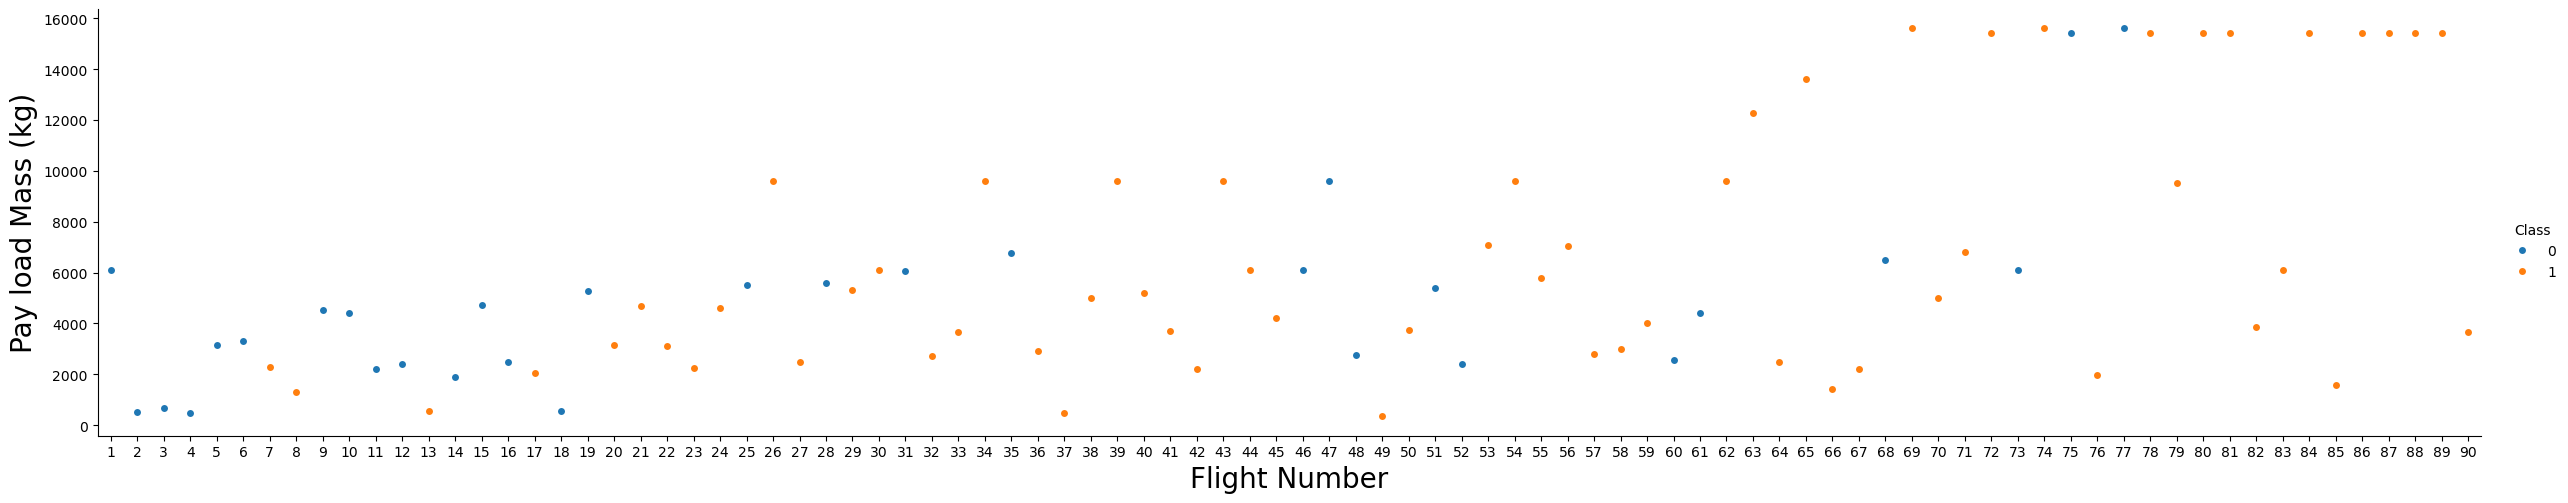

In [536]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

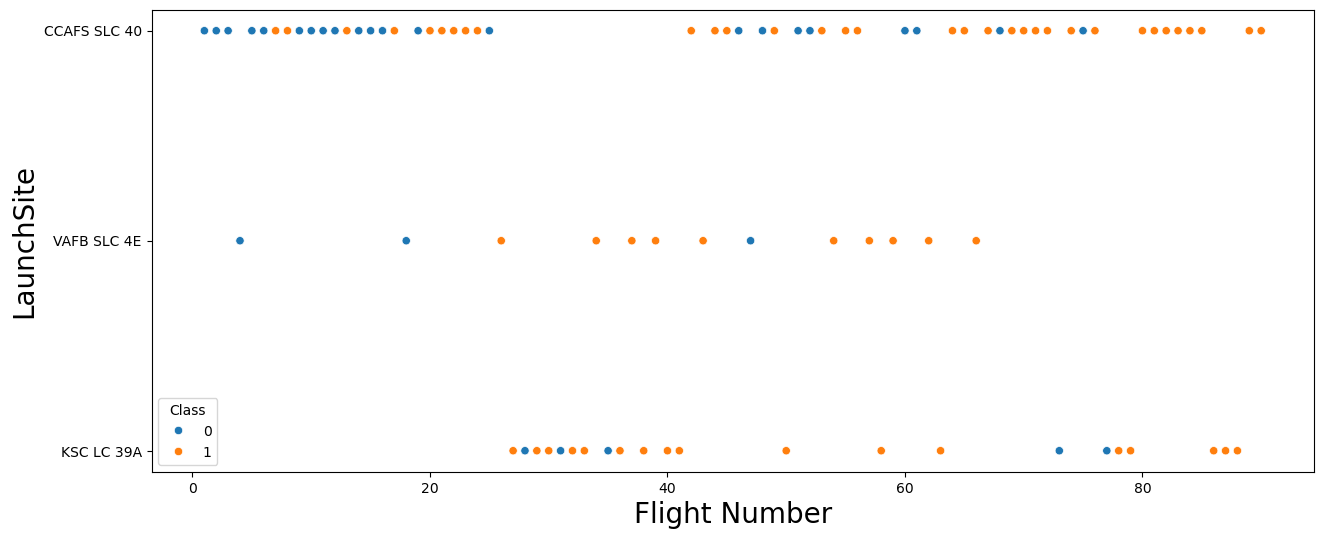

In [537]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the figure with a wide aspect ratio
plt.figure(figsize=(15, 6)) # Adjust width (15) and height (6) as needed

sns.scatterplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df)

plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("LaunchSite", fontsize=20)
plt.show()


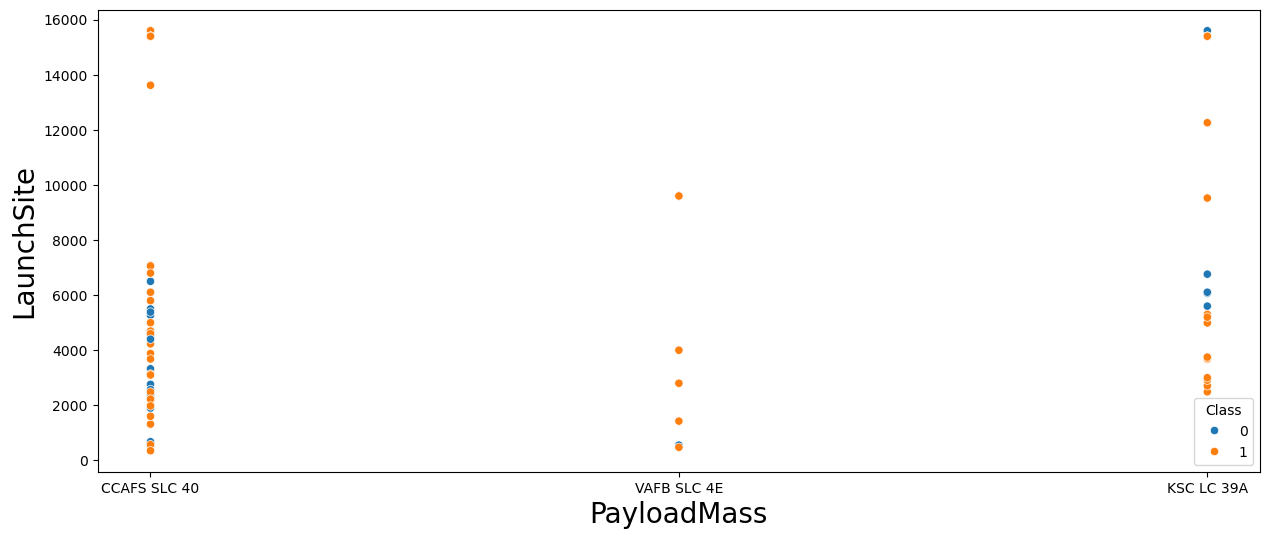

In [538]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value
import matplotlib.pyplot as plt
import seaborn as sns

# Create the figure with a wide aspect ratio
plt.figure(figsize=(15, 6)) # Adjust width (15) and height (6) as needed

sns.scatterplot(y="PayloadMass", x="LaunchSite", hue="Class", data=df)

plt.xlabel("PayloadMass", fontsize=20)
plt.ylabel("LaunchSite", fontsize=20)
plt.show()

    Orbit     Class
0   ES-L1  1.000000
1     GEO  1.000000
2     GTO  0.518519
3     HEO  1.000000
4     ISS  0.619048
5     LEO  0.714286
6     MEO  0.666667
7      PO  0.666667
8      SO  0.000000
9     SSO  1.000000
10   VLEO  0.857143


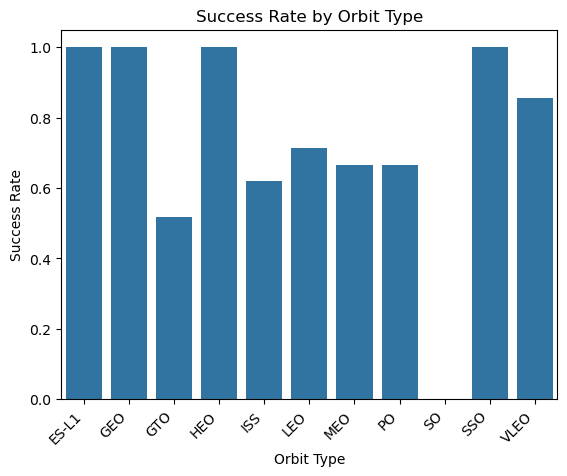

In [539]:
# HINT use groupby method on Orbit column and get the mean of Class column
success_rate=df.groupby('Orbit')['Class'].mean().reset_index()
print(success_rate)
sns.barplot(data=success_rate, x='Orbit', y='Class')

# Add titles and labels for clarity
plt.title('Success Rate by Orbit Type')
plt.xlabel('Orbit Type')
plt.ylabel('Success Rate')

# Rotate the x-axis labels for better readability if needed
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.show()

     LaunchSite     Class
0  CCAFS SLC 40  0.600000
1    KSC LC 39A  0.772727
2   VAFB SLC 4E  0.769231


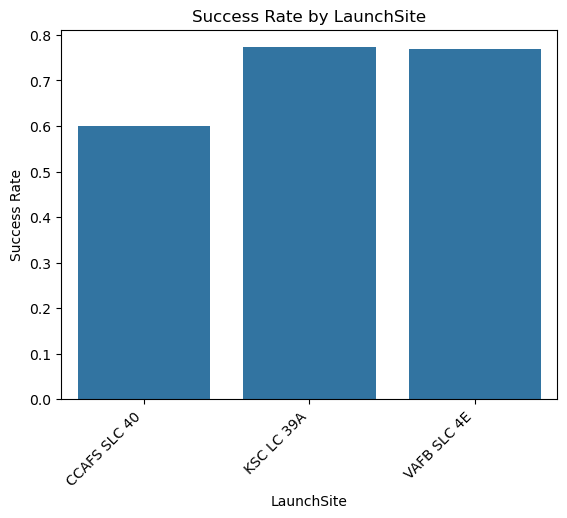

In [540]:
success_rate=df.groupby('LaunchSite')['Class'].mean().reset_index()
print(success_rate)
sns.barplot(data=success_rate, x='LaunchSite', y='Class')

# Add titles and labels for clarity
plt.title('Success Rate by LaunchSite')
plt.xlabel('LaunchSite')
plt.ylabel('Success Rate')

# Rotate the x-axis labels for better readability if needed
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.show()

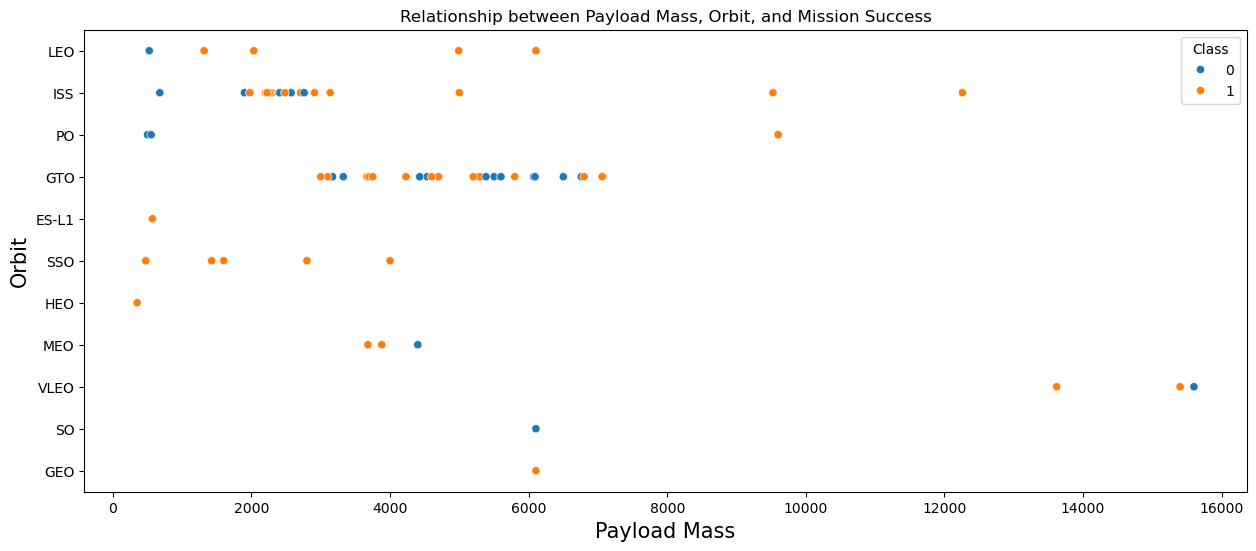

In [543]:
# Plot a scatter point chart with x axis to be Payload Mass and y axis to be the Orbit, and hue to be the class value
# Create a figure with a specific size to make the plot readable
plt.figure(figsize=(15, 6))

# Plot a scatter chart
sns.scatterplot(
    data=df,
    x='PayloadMass',
    y='Orbit',
    hue='Class' # Use the 'Class' column to color the points
)

plt.xlabel("Payload Mass", fontsize=15)
plt.ylabel("Orbit", fontsize=15)
plt.title("Relationship between Payload Mass, Orbit, and Mission Success")
plt.show()

In [546]:
df.columns

Index(['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit',
       'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs',
       'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude',
       'Class'],
      dtype='object')

In [548]:
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


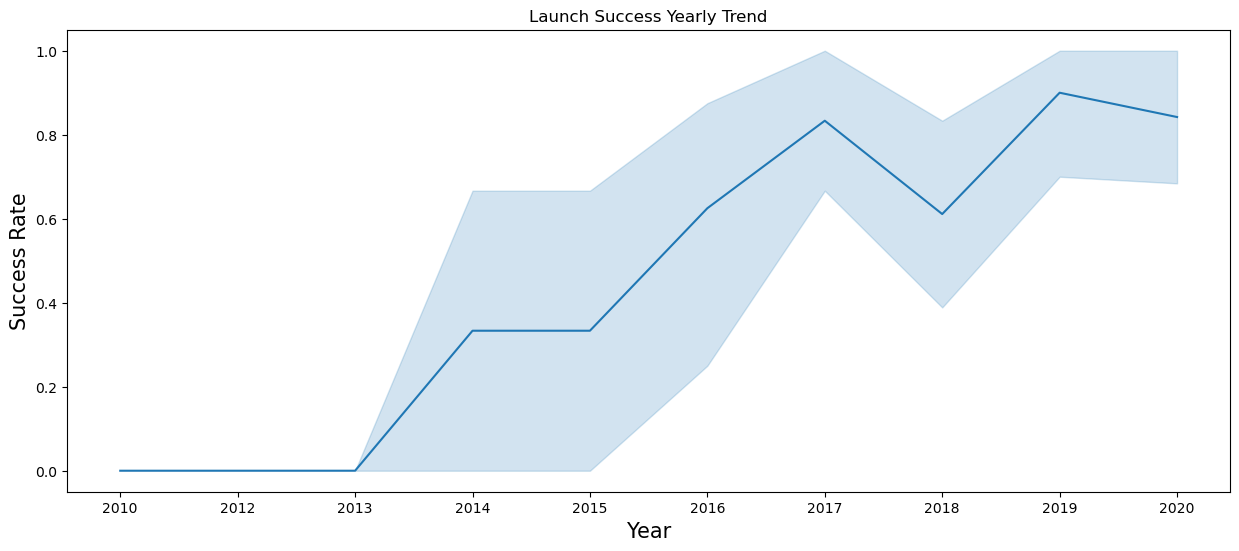

In [552]:
# Plot a line chart with x axis to be the extracted year and y axis to be the success rate
# Create a figure with a specific size to make the plot readable
plt.figure(figsize=(15, 6))
sns.lineplot(
    data=df,
    x='Date',
    y='Class'
)

plt.xlabel("Year", fontsize=15)
plt.ylabel("Success Rate", fontsize=15)
plt.title("Launch Success Yearly Trend")
plt.show()

###Features Engineering'
##By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.

In [555]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### TASK 11: Create dummy variables to categorical columns
Use the function get_dummies and features dataframe to apply OneHotEncoder to the column Orbits, LaunchSite, LandingPad, and Serial. Assign the value to the variable features_one_hot, display the results using the method head. Your result dataframe must include all features including the encoded ones.

In [207]:
# HINT: Use get_dummies() function on the categorical columns
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])

# Display the results using the head() method
print(features_one_hot.head())

   FlightNumber  PayloadMass  Flights  GridFins  Reused   Legs  Block  \
0             1  6104.959412        1     False   False  False    1.0   
1             2   525.000000        1     False   False  False    1.0   
2             3   677.000000        1     False   False  False    1.0   
3             4   500.000000        1     False   False  False    1.0   
4             5  3170.000000        1     False   False  False    1.0   

   ReusedCount  Orbit_ES-L1  Orbit_GEO  Orbit_GTO  Orbit_HEO  Orbit_ISS  \
0            0        False      False      False      False      False   
1            0        False      False      False      False      False   
2            0        False      False      False      False       True   
3            0        False      False      False      False      False   
4            0        False      False       True      False      False   

   Orbit_LEO  Orbit_MEO  Orbit_PO  Orbit_SO  Orbit_SSO  Orbit_VLEO  \
0       True      False     False     Fa

In [209]:
# HINT: use astype function
features_one_hot = features_one_hot.astype('float64')

# Display the data types to confirm the change
print(features_one_hot.dtypes)

FlightNumber    float64
PayloadMass     float64
Flights         float64
GridFins        float64
Reused          float64
                 ...   
Serial_B1056    float64
Serial_B1058    float64
Serial_B1059    float64
Serial_B1060    float64
Serial_B1062    float64
Length: 80, dtype: object


In [211]:
print(features_one_hot.head())

   FlightNumber  PayloadMass  Flights  GridFins  Reused  Legs  Block  \
0           1.0  6104.959412      1.0       0.0     0.0   0.0    1.0   
1           2.0   525.000000      1.0       0.0     0.0   0.0    1.0   
2           3.0   677.000000      1.0       0.0     0.0   0.0    1.0   
3           4.0   500.000000      1.0       0.0     0.0   0.0    1.0   
4           5.0  3170.000000      1.0       0.0     0.0   0.0    1.0   

   ReusedCount  Orbit_ES-L1  Orbit_GEO  Orbit_GTO  Orbit_HEO  Orbit_ISS  \
0          0.0          0.0        0.0        0.0        0.0        0.0   
1          0.0          0.0        0.0        0.0        0.0        0.0   
2          0.0          0.0        0.0        0.0        0.0        1.0   
3          0.0          0.0        0.0        0.0        0.0        0.0   
4          0.0          0.0        0.0        1.0        0.0        0.0   

   Orbit_LEO  Orbit_MEO  Orbit_PO  Orbit_SO  Orbit_SSO  Orbit_VLEO  \
0        1.0        0.0       0.0       0.0   

###TASK 1: Mark all launch sites on a map
##TASK 2: Mark the success/failed launches for each site on the map
#TASK 3: Calculate the distances between a launch site to its proximities
#After completed the above tasks, you should be able to find some geographical patterns about launch sites.

## 7. Geospatial Analysis Using Folium

Geospatial visualization is used to explore the locations of SpaceX launch sites.

Using the **Folium** library, interactive maps are created to visualize:

- Launch site coordinates
- Successful vs failed launches
- Proximity to infrastructure such as coastlines, highways, and railways

This analysis helps identify geographical factors influencing launch operations.

In [214]:
!pip install folium pandas

In [215]:
import folium
import pandas as pd

In [216]:
# Import folium MarkerCluster plugin for making cluster for sorting big data
from folium.plugins import MarkerCluster
# Import folium MousePosition plugin for marking positions
from folium.plugins import MousePosition
# Import folium DivIcon plugin for adding text
from folium.features import DivIcon

### Task 12: Mark all launch sites on a map

In [218]:
URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_geo.csv'

# Directly read CSV from URL
spacex_df = pd.read_csv(URL)

spacex_df.head()

,Flight Number,Date,Time (UTC),Booster Version,Launch Site,Payload,Payload Mass (kg),Orbit,Customer,Landing Outcome,class,Lat,Long
0,1,2010-06-04,18:45:00,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0.0,LEO,SpaceX,Failure (parachute),0,28.562302,-80.577356
1,2,2010-12-08,15:43:00,F9 v1.0 B0004,CCAFS LC-40,"Dragon demo flight C1, two CubeSats, barrel of Brouère cheese",0.0,LEO (ISS),NASA (COTS) NRO,Failure (parachute),0,28.562302,-80.577356
2,3,2012-05-22,7:44:00,F9 v1.0 B0005,CCAFS LC-40,Dragon demo flight C2+,525.0,LEO (ISS),NASA (COTS),No attempt,0,28.562302,-80.577356
3,4,2012-10-08,0:35:00,F9 v1.0 B0006,CCAFS LC-40,SpaceX CRS-1,500.0,LEO (ISS),NASA (CRS),No attempt,0,28.562302,-80.577356
4,5,2013-03-01,15:10:00,F9 v1.0 B0007,CCAFS LC-40,SpaceX CRS-2,677.0,LEO (ISS),NASA (CRS),No attempt,0,28.562302,-80.577356


In [219]:
# Select relevant sub-columns: `Launch Site`, `Lat(Latitude)`, `Long(Longitude)`, `class`
spacex_df = spacex_df[['Launch Site', 'Lat', 'Long', 'class']]
launch_sites_df = spacex_df.groupby(['Launch Site'], as_index=False).first()
launch_sites_df = launch_sites_df[['Launch Site', 'Lat', 'Long']]
launch_sites_df

,Launch Site,Lat,Long
0,CCAFS LC-40,28.562302,-80.577356
1,CCAFS SLC-40,28.563197,-80.576820
2,KSC LC-39A,28.573255,-80.646895
3,VAFB SLC-4E,34.632834,-120.610745


In [220]:
#We first need to create a folium Map object, with an initial center location to be NASA Johnson Space Center at Houston, Texas.
# Start location is NASA Johnson Space Center
nasa_coordinate = [29.559684888503615, -95.0830971930759]
site_map = folium.Map(location=nasa_coordinate, zoom_start=10)

In [221]:
# Create a blue circle at NASA Johnson Space Center's coordinate with a popup label showing its name
circle = folium.Circle(nasa_coordinate, radius=1000, color='#d35400', fill=True).add_child(folium.Popup('NASA Johnson Space Center'))
# Create a blue circle at NASA Johnson Space Center's coordinate with a icon showing its name
marker = folium.map.Marker(
    nasa_coordinate,
    # Create an icon as a text label
    icon=DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % 'NASA JSC',
        )
    )
site_map.add_child(circle)
site_map.add_child(marker)

## 8. Launch Site Clustering

Clustering techniques are used to group launch sites based on geographical coordinates.

By analyzing spatial relationships between launch sites, we can identify patterns in launch activity and understand how geographic factors may impact mission operations.

Clustering also helps visualize the spatial distribution of launch locations.

In [222]:
import folium
from folium.plugins import MarkerCluster
from folium.features import DivIcon

# --- Initialize the map ---
site_map = folium.Map(location=nasa_coordinate, zoom_start=5)

# --- Add MarkerCluster ---
marker_cluster = MarkerCluster().add_to(site_map)

# --- Add markers for each launch site ---
for i, row in launch_sites_df.iterrows():
    folium.Marker(
        location=[row['Lat'], row['Long']],
        popup=row['Launch Site'],
        icon=DivIcon(
            icon_size=(20, 20),
            icon_anchor=(0, 0),
            html='<div style="font-size: 12pt; color:#d35400;"><b>{}</b></div>'.format(row['Launch Site'])
        )
    ).add_to(marker_cluster)

# --- Display the map ---
site_map


In [223]:
import folium
from folium.plugins import MarkerCluster

# --- Initialize the map ---
site_map = folium.Map(location=[28, -80], zoom_start=4)

# --- Add MarkerCluster ---
marker_cluster = MarkerCluster().add_to(site_map)

# --- Add all launch markers without printing anything ---
for i, row in spacex_df.iterrows():
    color = 'green' if row['class'] == 1 else 'red'
    folium.CircleMarker(
        location=[row['Lat'], row['Long']],
        radius=6,
        color=color,
        fill=True,
        fill_color=color,
        popup=f"Site: {row['Launch Site']}\nOutcome: {'Success' if row['class']==1 else 'Failure'}"
    ).add_to(marker_cluster)

# --- Display map ONLY once ---
site_map

In [225]:
import folium
from folium.plugins import MarkerCluster

# --- Initialize the map ---
site_map = folium.Map(location=[28, -80], zoom_start=4)

# --- Add a MarkerCluster ---
marker_cluster = MarkerCluster().add_to(site_map)

for i, row in spacex_df.iterrows():
    _ = folium.CircleMarker(
        location=[row['Lat'], row['Long']],
        radius=6,
        color='green' if row['class']==1 else 'red',
        fill=True,
        fill_color='green' if row['class']==1 else 'red',
        popup=f"Site: {row['Launch Site']}\nOutcome: {'Success' if row['class']==1 else 'Failure'}"
    ).add_to(marker_cluster)

# --- Display map ---
site_map


In [228]:
# Create marker_color column
spacex_df['marker_color'] = spacex_df['class'].apply(lambda x: 'green' if x == 1 else 'red')
spacex_df[['class', 'marker_color']].head(20)

,class,marker_color
0,0,red
1,0,red
2,0,red
3,0,red
4,0,red
5,0,red
6,0,red
7,0,red
8,0,red
9,0,red


In [229]:
import folium
from folium.plugins import MarkerCluster
import pandas as pd

# --- 1) Create marker_color column based on the 'class' column (1 -> green, 0 -> red) ---
spacex_df['marker_color'] = spacex_df['class'].apply(lambda x: 'green' if x == 1 else 'red')

# --- 2) Initialize the map (center it roughly on the launch sites) ---
center_lat = spacex_df['Lat'].mean()
center_lon = spacex_df['Long'].mean()
site_map = folium.Map(location=[center_lat, center_lon], zoom_start=4)

# --- 3) Create a MarkerCluster and add it to the map ---
marker_cluster = MarkerCluster().add_to(site_map)

# --- 4) Add one marker per launch record to the cluster (no printing inside loop) ---
for _, row in spacex_df.iterrows():
    lat, lon = row['Lat'], row['Long']
    # skip rows with missing coordinates
    if pd.isna(lat) or pd.isna(lon):
        continue

    popup_html = f"Site: {row['Launch Site']}<br>Outcome: {'Success' if row['class'] == 1 else 'Failure'}"
    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(popup_html, max_width=300),
        icon=folium.Icon(color='white', icon_color=row['marker_color'])  # marker color shown via icon_color
    ).add_to(marker_cluster)

# --- 5) Display the map (only this line should produce output in Jupyter) ---
site_map

### TASK 13: Calculate the distances between a launch site to its proximities

In [238]:
# Add Mouse Position to get the coordinate (Lat, Long) for a mouse over on the map
formatter = "function(num) {return L.Util.formatNum(num, 5);};"
mouse_position = MousePosition(
    position='topright',
    separator=' Long: ',
    empty_string='NaN',
    lng_first=False,
    num_digits=20,
    prefix='Lat:',
    lat_formatter=formatter,
    lng_formatter=formatter,
)

site_map.add_child(mouse_position)
site_map

In [241]:
from math import sin, cos, sqrt, atan2, radians

def calculate_distance(lat1, lon1, lat2, lon2):
    # approximate radius of earth in km
    R = 6373.0

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c
    return distance

In [242]:
# find coordinate of the closet coastline
# e.g.,: Lat: 28.56367  Lon: -80.57163
# distance_coastline = calculate_distance(launch_site_lat, launch_site_lon, coastline_lat, coastline_lon
# launch site coordinates
launch_site_lat = 28.56230
launch_site_lon = -80.57736

# manually selected coastline coordinates using mouse hover
coastline_lat = 28.56367
coastline_lon = -80.57163

# calculate distance
distance_coastline = calculate_distance(
    launch_site_lat, launch_site_lon,
    coastline_lat, coastline_lon
)

print("Distance to coastline:", distance_coastline, "km")

Distance to coastline: 0.5801475319882505 km


In [245]:
# Selected coastline coordinate using mouse hover
coastline_lat = 28.5633
coastline_lon = -80.5718

launch_site_lat = 28.5623
launch_site_lon = -80.5774

distance = calculate_distance(launch_site_lat, launch_site_lon, coastline_lat, coastline_lon)

# Add marker for coastline
folium.Marker(
    [coastline_lat, coastline_lon],
    popup="Coastline Point",
    icon=folium.Icon(color='blue')
).add_to(site_map)

# Add text label showing distance
distance_marker = folium.Marker(
    [coastline_lat, coastline_lon],
    icon=DivIcon(
        icon_size=(80, 20),
        icon_anchor=(0, 0),
        html='<div style="font-size:14px; color:#d35400;"><b>{:.2f} km</b></div>'.format(distance)
    )
)

site_map.add_child(distance_marker)
site_map


In [248]:
lines = folium.PolyLine(
    locations=[[launch_site_lat, launch_site_lon], [coastline_lat, coastline_lon]],
    weight=2
)
site_map.add_child(lines)

In [249]:
launch_site_lat = 36.56409
launch_site_lon = -119.35439

# manually selected coastline coordinates using mouse hover
city_lat = 34.93725
city_lon = -120.43586
highway_lat = 34.70116
highway_lon = -120.47182
railroad_lat = 33.84912
railroad_lon = -118.34036
# calculate distance
distance_city = calculate_distance(
    launch_site_lat, launch_site_lon,
    city_lat, city_lon
)
distance_highway = calculate_distance(
    launch_site_lat, launch_site_lon,
    highway_lat, highway_lon
)
distance_railroad = calculate_distance(
    launch_site_lat, launch_site_lon,
    railroad_lat, railroad_lon
)
print("Distance to city:", distance_city, "km")
print("Distance to highway:", distance_highway, "km")
print("Distance to railroad:", distance_railroad, "km")

Distance to city: 205.60377297320545 km
Distance to highway: 230.52137608490187 km
Distance to railroad: 315.7285361912283 km


In [252]:
lines1 = folium.PolyLine(
    locations=[[launch_site_lat, launch_site_lon], [city_lat, city_lon]],
    weight=2
)
site_map.add_child(lines1)

In [254]:
lines2 = folium.PolyLine(
    locations=[[launch_site_lat, launch_site_lon], [highway_lat, highway_lon]],
    weight=2
)
site_map.add_child(lines2)

In [256]:
lines3 = folium.PolyLine(
    locations=[[launch_site_lat, launch_site_lon], [railroad_lat, railroad_lon]],
    weight=2
)
site_map.add_child(lines3)

In [258]:
pip install jupyter-dash

## 9. Interactive Dashboard

An interactive dashboard is built using **Plotly Dash** to visualize SpaceX launch records.

The dashboard allows users to:

- Filter launches by site
- Explore launch success distribution
- Analyze payload mass relationships
- Visualize launch performance interactively

This dashboard transforms the analysis into an interactive exploration tool.

In [260]:
# Import required libraries
import pandas as pd
import dash
from dash import html
from dash import dcc
from dash.dependencies import Input, Output
import plotly.express as px
import sys

# Read the airline data into pandas dataframe
# Ensure your file path is correct for your notebook environment

spacex_df = pd.read_csv(r"c:\Users\user\OneDrive\Desktop\dash application course10\spacex_launch_dash.csv.csv")


max_payload = spacex_df['Payload Mass (kg)'].max()
min_payload = spacex_df['Payload Mass (kg)'].min()

# Create a dash application
app = dash.Dash(__name__)

# Create an app layout
app.layout = html.Div(children=[
    html.H1('SpaceX Launch Records Dashboard',
            style={'textAlign': 'center', 'color': '#503D36', 'font-size': 40}),
    
    # TASK 1: Add a dropdown list to enable Launch Site selection
    dcc.Dropdown(
        id='site-dropdown',
        options=[
            {'label': 'All Sites', 'value': 'ALL'},
            {'label': 'CCAFS LC-40', 'value': 'CCAFS LC-40'},
            {'label': 'VAFB SLC-4E', 'value': 'VAFB SLC-4E'},
            {'label': 'KSC LC-39A', 'value': 'KSC LC-39A'},
            {'label': 'CCAFS SLC-40', 'value': 'CCAFS SLC-40'},
        ],
        value='ALL',
        placeholder="Select a Launch Site here",
        searchable=True,
        style={'width': '80%', 'margin': '0 auto'}
    ),
    html.Br(),

    # TASK 2: Add a pie chart to show the total successful launches
    html.Div(dcc.Graph(id='success-pie-chart')),
    html.Br(),

    html.P("Payload range (Kg):"),
    
    # TASK 3: Add a slider to select payload range
    dcc.RangeSlider(
        id='payload-slider',
        min=0,
        max=10000,
        step=1000,
        marks={
            0: '0', 2500: '2,500', 5000: '5,000',
            7500: '7,500', 10000: '10,000'
        },
        value=[max(0, int(min_payload)), min(10000, int(max_payload))],
        tooltip={"placement": "bottom", "always_visible": True},
        allowCross=False,
        updatemode='mouseup',
        className='payload-slider'
    ),
    
    # TASK 4: Add a scatter chart to show correlation
    html.Div(dcc.Graph(id='success-payload-scatter-chart')),
])

# TASK 2: Pie chart callback
@app.callback(
    Output(component_id='success-pie-chart', component_property='figure'),
    Input(component_id='site-dropdown', component_property='value')
)
# ... some other code ...
def get_pie_chart(entered_site):
    if entered_site == 'ALL':
        # When 'ALL' is selected, create a pie chart showing total success by each launch site
        fig = px.pie(
            spacex_df, 
            values='class', 
            names='Launch Site', 
            title='Total Success Launches by Site'
        )
    else:
        # When a specific site is selected, filter the data and create a pie chart
        filtered_df = spacex_df[spacex_df['Launch Site'] == entered_site]

        # Count the outcomes for the specific site
        outcome_counts = filtered_df['class'].map({1: 'Success', 0: 'Failure'}).value_counts().reset_index()
        outcome_counts.columns = ['outcome', 'count']

        # Create a pie chart from the outcome counts
        fig = px.pie(
            outcome_counts, 
            values='count',  # Use the 'count' column for values
            names='outcome',  # Use the 'outcome' column for names
            title=f'Total Success vs. Failure for site {entered_site}'
        )

    return fig

# TASK 4: Scatter chart callback
@app.callback(
    Output(component_id='success-payload-scatter-chart', component_property='figure'),
    [
        Input(component_id='site-dropdown', component_property='value'),
        Input(component_id='payload-slider', component_property='value')
    ]
)
def update_scatter(selected_site, payload_range):
    low, high = payload_range
    
    # Filter data by payload first
    filtered_df = spacex_df[
        (spacex_df['Payload Mass (kg)'] >= low) &
        (spacex_df['Payload Mass (kg)'] <= high)
    ]
    
    if selected_site == 'ALL':
        fig = px.scatter(
            filtered_df,
            x="Payload Mass (kg)",
            y="class",
            color="Booster Version Category",
            title="Correlation between Payload and Success for all Sites"
        )
        return fig
    else:
        site_df = filtered_df[filtered_df["Launch Site"] == selected_site]
        
        fig = px.scatter(
            site_df,
            x="Payload Mass (kg)",
            y="class",
            color="Booster Version Category",
            title=f"Correlation between Payload and Success for site {selected_site}"
        )
        return fig

if __name__ == '__main__':
    # We use port 8051 as a different port to avoid conflicts
    app.run(debug=True, port=8051)



In [261]:
pip install "dash[cloud]"

Note: you may need to restart the kernel to use updated packages.


## 10. Correlation Analysis

A correlation matrix is used to analyze relationships between variables in the dataset.

This helps identify which features may influence booster landing success, including:

- Payload mass
- Orbit type
- Launch site
- Booster reuse

Understanding these relationships is useful for feature selection in machine learning models.

In [262]:
import numpy as np
import pandas as pd
import seaborn as sns

In [263]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

In [264]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

In [265]:
import pandas as pd

# Load dataset 1
URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
data = pd.read_csv(URL1)
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [266]:
# Load dataset 2
URL2 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv"
X = pd.read_csv(URL2)
X.head()

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [267]:
Y=data['Class'].to_numpy()

In [268]:
# students get this 
transform = preprocessing.StandardScaler()
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [270]:
# Look for this line in your code
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [271]:
print(Y_test.shape)
print(X_test.shape)
print(Y_train.shape)
print(X_train.shape)

(18,)
(18, 83)
(72,)
(72, 83)


## 11. Machine Learning Models & Model Evaluation

Machine learning models are trained to predict whether a Falcon 9 first-stage booster will land successfully.

The models evaluated include:

- Logistic Regression
- Support Vector Machines (SVM)
- Decision Trees
- K-Nearest Neighbors (KNN)

These models use launch characteristics as input features to predict landing outcomes.

The performance of each machine learning model is evaluated using classification metrics.

Evaluation methods include:

- Accuracy score
- Confusion matrix
- Model comparison

The best performing model provides insight into which launch factors contribute most to successful booster landings.

#TASK 4
Create a logistic regression object then create a GridSearchCV object logreg_cv with cv = 10. Fit the object to find the best parameters from the dictionary parameters.



tuned hpyerparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8464285714285713
Test Accuracy: 0.8333333333333334


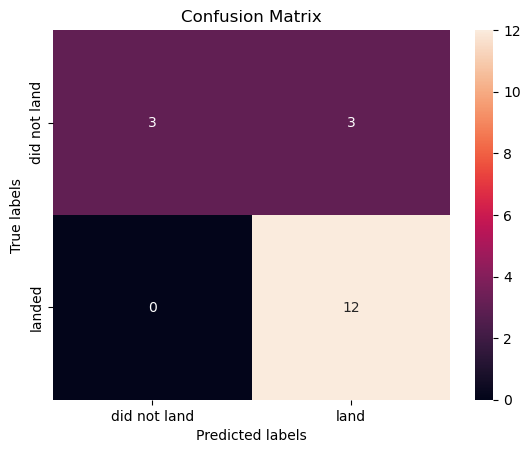

In [274]:
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
lr=LogisticRegression()
logreg_cv=GridSearchCV(lr,parameters,cv=10)
logreg_cv.fit(X_train, Y_train)
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)
test_accuracy = logreg_cv.best_estimator_.score(X_test, Y_test)
print("Test Accuracy:", test_accuracy)
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

###Create a support vector machine object then create a GridSearchCV object svm_cv with cv = 10. Fit the object to find the best parameters from the dictionary parameters.

tuned hpyerparameters :(best parameters)  {'C': 1.0, 'gamma': 0.03162277660168379, 'kernel': 'sigmoid'}
accuracy : 0.8482142857142856
Test Accuracy: 0.8333333333333334


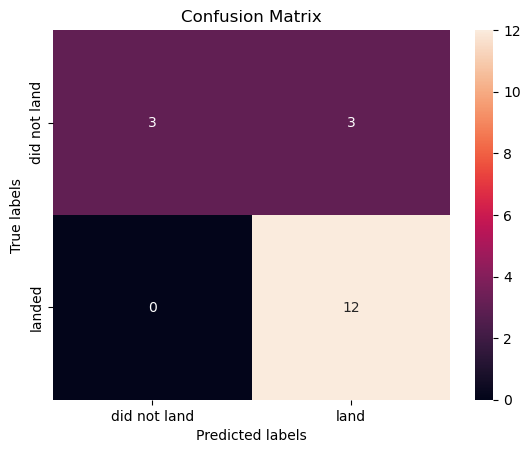

In [276]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv=GridSearchCV(svm,parameters,cv=10)
svm_cv.fit(X_train,Y_train)
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)
test_accuracy = svm_cv.best_estimator_.score(X_test, Y_test)
print("Test Accuracy:", test_accuracy)
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

#Create a decision tree classifier object then create a GridSearchCV object tree_cv with cv = 10. Fit the object to find the best parameters from the dictionary parameters.

C:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning:


3240 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3240 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "C:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\user\anaconda3\Lib\site-package

tuned hpyerparameters :(best parameters)  {'criterion': 'entropy', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
accuracy : 0.8607142857142858
Test Accuracy: 0.6666666666666666


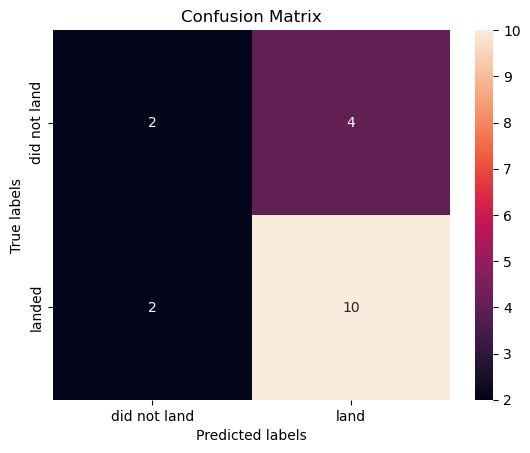

In [290]:
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['auto', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()
tree_cv=GridSearchCV(tree,parameters,cv=10)
tree_cv.fit(X_train,Y_train)
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)
test_accuracy = tree_cv.best_estimator_.score(X_test, Y_test)
print("Test Accuracy:", test_accuracy)
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

#Create a k nearest neighbors object then create a GridSearchCV object knn_cv with cv = 10. Fit the object to find the best parameters from the dictionary parameters

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
accuracy : 0.8482142857142858
Test Accuracy: 0.8333333333333334


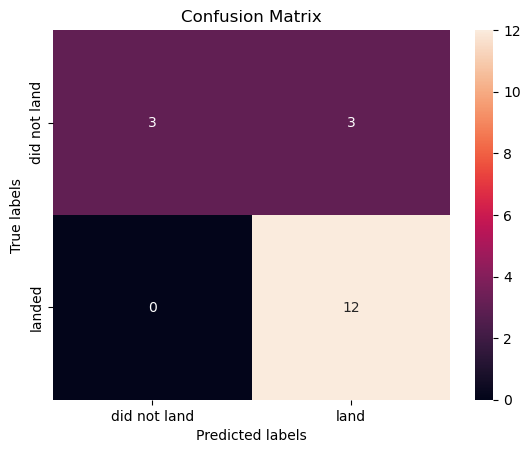

In [292]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()
knn_cv=GridSearchCV(KNN,parameters,cv=10)
knn_cv.fit(X_train,Y_train)
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)
test_accuracy = knn_cv.best_estimator_.score(X_test, Y_test)
print("Test Accuracy:", test_accuracy)
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

### Find the method performs best:

In [294]:
models = {
    "Logistic Regression": logreg_cv.best_estimator_,
    "SVM": svm_cv.best_estimator_,
    "Decision Tree": tree_cv.best_estimator_,
    "KNearestNeighbors": knn_cv.best_estimator_
}

for name, model in models.items():
    print(name, "Test Accuracy:", model.score(X_test, Y_test))

Logistic Regression Test Accuracy: 0.8333333333333334
SVM Test Accuracy: 0.8333333333333334
Decision Tree Test Accuracy: 0.6666666666666666
KNearestNeighbors Test Accuracy: 0.8333333333333334


## Conclusion

This project demonstrates an end-to-end data science workflow using SpaceX Falcon 9 launch data.

By combining API data collection, web scraping, geospatial mapping, clustering, exploratory analysis, and machine learning modeling, the analysis reveals important patterns related to launch success and booster landing outcomes.

The results highlight how operational factors such as payload mass, launch site location, and mission characteristics influence the likelihood of successful first-stage landings.

Interactive dashboards further enhance the analysis by allowing users to explore launch records dynamically.

Overall, this project provides valuable insights into SpaceX launch operations while demonstrating practical applications of data science techniques.